## Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS

<table>
<tr>
<th>Componente</th>
<th>Descripción</th>
</tr>

<tr>
<td><strong>Percepción (S)</strong></td>
<td>
<ul>
<li><strong>Ingreso mensual:</strong> cantidad de dinero que percibe el solicitante cada mes, expresada en soles.</li>
<li><strong>Monto solicitado:</strong> cantidad de dinero que el solicitante desea obtener como crédito, expresada en soles.</li>
<li><strong>Historial moroso:</strong> indica si el solicitante presenta antecedentes de morosidad (<code>True</code> o <code>False</code>).</li>
<li><strong>Relación monto/ingreso:</strong> valor calculado mediante <code>monto_solicitado / ingreso_mensual</code>.</li>
</ul>
</td>
</tr>

<tr>
<td><strong>Entorno (E)</strong></td>
<td>
Sistema bancario de evaluación automática de solicitudes de crédito, donde se analiza la información financiera proporcionada por el solicitante.
</td>
</tr>

<tr>
<td><strong>Acciones (A)</strong></td>
<td>
<ul>
<li><strong>Aprobar</strong> la solicitud.</li>
<li><strong>Aprobar con condiciones</strong> la solicitud.</li>
<li><strong>Rechazar</strong> la solicitud.</li>
</ul>
</td>
</tr>

<tr>
<td><strong>Medida de desempeño (P)</strong></td>
<td>
Tomar decisiones coherentes con el nivel de riesgo de la solicitud, considerando la relación entre el monto solicitado y el ingreso mensual, así como el historial moroso del solicitante.
</td>
</tr>

</table>

### Justificación de las reglas

Las reglas consideran la relación entre el monto solicitado y el ingreso mensual para estimar la capacidad de pago del solicitante. Una relación baja representa un menor nivel de riesgo para el banco, mientras que una relación elevada implica una mayor carga financiera. Cuando existe historial moroso, se aplican condiciones más restrictivas debido al antecedente de incumplimiento. Por ello, el agente combina la relación monto/ingreso y el historial para decidir entre aprobar, aprobar con condiciones o rechazar.

### Código

La función `agente_credito` evalúa una solicitud de crédito utilizando la relación entre el monto solicitado y el ingreso mensual, junto con el historial de morosidad del solicitante. Como resultado, retorna una acción y el motivo que explica la decisión tomada.

In [2]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    
    if ingreso_mensual <= 0:
        return (
            "rechazar",
            "ingreso mensual inválido o menor o igual a cero"
        )

    relacion = monto_solicitado / ingreso_mensual

    if tiene_historial_moroso and relacion > 0.30:
        return (
            "rechazar",
            f"relación monto/ingreso de {relacion:.2f} "
            "mayor a 0.30 con historial moroso"
        )

    elif relacion > 0.50:
        return (
            "rechazar",
            f"relación monto/ingreso de {relacion:.2f} "
            "mayor a 0.50"
        )

    elif tiene_historial_moroso:
        return (
            "aprobar con condiciones",
            f"relación monto/ingreso de {relacion:.2f} "
            "con historial moroso"
        )

    elif relacion <= 0.30:
        return (
            "aprobar",
            f"relación monto/ingreso de {relacion:.2f} "
            "sin historial moroso"
        )

    else:
        return (
            "aprobar con condiciones",
            f"relación monto/ingreso de {relacion:.2f} "
            "entre 0.30 y 0.50"
        )

### Simulación y pruebas

Se realizan diferentes combinaciones de ingreso mensual, monto solicitado e historial moroso para verificar el comportamiento del agente. Se incluyen casos normales y casos límite para comprobar las reglas de decisión.

In [5]:
# Casos de prueba para el agente de crédito

pruebas = [
    # Caso 1: relación baja, sin historial moroso
    (3000, 600, False),

    # Caso 2: relación media, sin historial moroso
    (3000, 900, False),

    # Caso 3: límite de 0.50, sin historial moroso
    (3000, 1500, False),

    # Caso 4: relación alta, sin historial moroso
    (3000, 1800, False),

    # Caso 5: relación 0.30, con historial moroso
    (3000, 900, True),

    # Caso 6: relación 0.40, con historial moroso
    (3000, 1200, True),

    # Caso 7: relación baja, sin historial moroso
    (5000, 1000, False),

    # Caso 8: relación alta, con historial moroso
    (5000, 3000, True)
]

for i, (ingreso, monto, moroso) in enumerate(pruebas, start=1):

    relacion = monto / ingreso

    accion, motivo = agente_credito(
        ingreso,
        monto,
        moroso
    )

    print(f"PRUEBA {i}")
    print(f"Ingreso mensual: S/ {ingreso:,.2f}")
    print(f"Monto solicitado: S/ {monto:,.2f}")
    print(f"Historial moroso: {moroso}")
    print(f"Relación monto/ingreso: {relacion:.2f}")
    print(f"Acción: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 60)

PRUEBA 1
Ingreso mensual: S/ 3,000.00
Monto solicitado: S/ 600.00
Historial moroso: False
Relación monto/ingreso: 0.20
Acción: aprobar
Motivo: relación monto/ingreso de 0.20 sin historial moroso
------------------------------------------------------------
PRUEBA 2
Ingreso mensual: S/ 3,000.00
Monto solicitado: S/ 900.00
Historial moroso: False
Relación monto/ingreso: 0.30
Acción: aprobar
Motivo: relación monto/ingreso de 0.30 sin historial moroso
------------------------------------------------------------
PRUEBA 3
Ingreso mensual: S/ 3,000.00
Monto solicitado: S/ 1,500.00
Historial moroso: False
Relación monto/ingreso: 0.50
Acción: aprobar con condiciones
Motivo: relación monto/ingreso de 0.50 entre 0.30 y 0.50
------------------------------------------------------------
PRUEBA 4
Ingreso mensual: S/ 3,000.00
Monto solicitado: S/ 1,800.00
Historial moroso: False
Relación monto/ingreso: 0.60
Acción: rechazar
Motivo: relación monto/ingreso de 0.60 mayor a 0.50
---------------------------

### Visualización

Se generan 200 solicitudes de crédito aleatorias para observar gráficamente el comportamiento del agente. Para cada solicitud se calcula la relación entre el monto solicitado y el ingreso mensual, y se determina la acción correspondiente. El gráfico representa la relación monto/ingreso frente al ingreso mensual, diferenciando las decisiones tomadas por el agente.

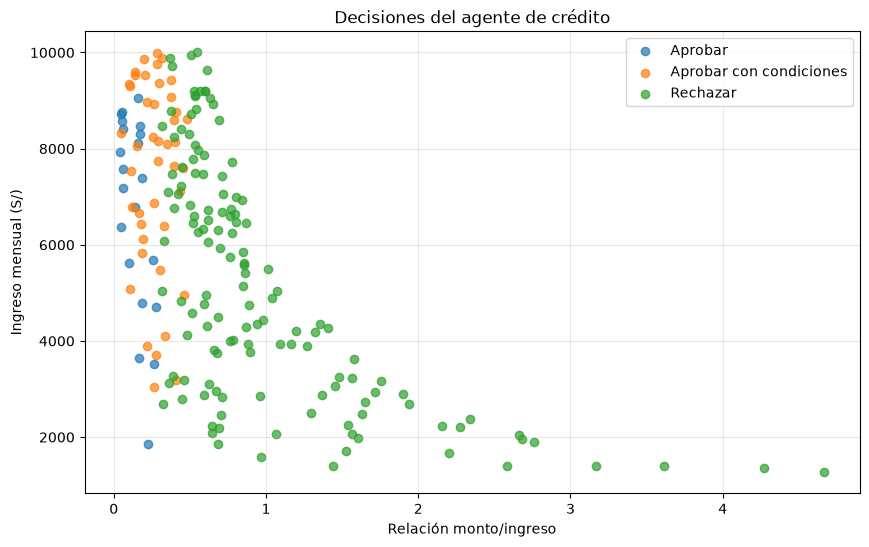

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Fijar una semilla para obtener resultados reproducibles
np.random.seed(42)

# Generar 200 solicitudes aleatorias
n_solicitudes = 200

ingresos = np.random.randint(1200, 10001, n_solicitudes)
montos = np.random.randint(300, 6001, n_solicitudes)
historial_moroso = np.random.choice(
    [False, True],
    size=n_solicitudes
)

# Calcular la relación monto/ingreso
relaciones = montos / ingresos

# Obtener la decisión del agente para cada solicitud
decisiones = []

for ingreso, monto, moroso in zip(
    ingresos,
    montos,
    historial_moroso
):
    accion, motivo = agente_credito(
        ingreso,
        monto,
        moroso
    )
    
    decisiones.append(accion)

# Convertir las decisiones a un arreglo de NumPy
decisiones = np.array(decisiones)

# Crear el gráfico
plt.figure(figsize=(10, 6))

# Graficar cada decisión
plt.scatter(
    relaciones[decisiones == "aprobar"],
    ingresos[decisiones == "aprobar"],
    label="Aprobar",
    alpha=0.7
)

plt.scatter(
    relaciones[decisiones == "aprobar con condiciones"],
    ingresos[decisiones == "aprobar con condiciones"],
    label="Aprobar con condiciones",
    alpha=0.7
)

plt.scatter(
    relaciones[decisiones == "rechazar"],
    ingresos[decisiones == "rechazar"],
    label="Rechazar",
    alpha=0.7
)

# Configuración del gráfico
plt.xlabel("Relación monto/ingreso")
plt.ylabel("Ingreso mensual (S/)")
plt.title("Decisiones del agente de crédito")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
print(f"Total de solicitudes: {len(decisiones)}")
print(f"Aprobadas: {np.sum(decisiones == 'aprobar')}")
print(f"Aprobadas con condiciones: {np.sum(decisiones == 'aprobar con condiciones')}")
print(f"Rechazadas: {np.sum(decisiones == 'rechazar')}")

Total de solicitudes: 200
Aprobadas: 21
Aprobadas con condiciones: 43
Rechazadas: 136
